<a href="https://colab.research.google.com/github/LCaravaggio/Happiness_Polarization/blob/main/Third_Places.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.9 MB/s eta 0:00:00


In [2]:
!wget https://www.latinobarometro.org/documents/LAT-2024/latinobarometro-2024-stata-v20250817.zip
!unzip latinobarometro-2024-stata-v20250817.zip

--2026-05-19 15:15:14--  https://www.latinobarometro.org/documents/LAT-2024/latinobarometro-2024-stata-v20250817.zip
Resolving www.latinobarometro.org (www.latinobarometro.org)... 80.28.53.190
Connecting to www.latinobarometro.org (www.latinobarometro.org)|80.28.53.190|:443... connected.
HTTP request sent, awaiting response... 200 200
Length: 6691592 (6.4M) [application/x-zip-compressed]
Saving to: ‘latinobarometro-2024-stata-v20250817.zip’

latinobarometro-202 100%[===================>]   6.38M  1.12MB/s    in 9.9s    

2026-05-19 15:15:25 (659 KB/s) - ‘latinobarometro-2024-stata-v20250817.zip’ saved [6691592/6691592]

Archive:  latinobarometro-2024-stata-v20250817.zip
  inflating: Latinobarometro_2024_Stata_eng_v20250817.dta  
  inflating: Latinobarometro_2024_Stata_esp_v20250817.dta  
  inflating: Latinobarometro_2024_Cuestionario_esp.pdf  
  inflating: Latinobarometro_2024_Cuestionario_eng.pdf  


In [3]:
import pandas as pd

# abrir reader
reader = pd.read_stata(
    "Latinobarometro_2024_Stata_esp_v20250817.dta",
    convert_categoricals=False,
    iterator=True
)

# dataframe
df24 = reader.read()

# labels de variables
variable_labels = reader.variable_labels()

# TODOS los value labels
value_labels = reader.value_labels()

In [4]:
value_labels["TAMCIUD"]

{np.int32(1): 'Menos de 5.000',
 np.int32(2): '5.001 - 10.000',
 np.int32(3): '10.001 - 20.000',
 np.int32(4): '20.001 - 40.000',
 np.int32(5): '40.001 - 50.000',
 np.int32(6): '50.001 - 100.000',
 np.int32(7): '100.001 y mas',
 np.int32(8): '(Capital)'}

In [5]:
import osmnx as ox

# =========================
# CONFIGURACIÓN
# =========================

place = "Rosario, Santa Fe, Argentina"
population = 1300000  # cambiar por la población de la ciudad

# =========================
# DESCARGAR POLÍGONO
# =========================

gdf = ox.geocode_to_gdf(place)
polygon = gdf.geometry.iloc[0]

# =========================
# DEFINIR "THIRD PLACES"
# =========================

tags = {
    "amenity": [
        "cafe",
        "bar",
        "pub",
        "library",
        "community_centre",
        "place_of_worship"
    ],
    "leisure": [
        "park",
        "sports_centre"
    ]
}

# =========================
# DESCARGAR POIs
# =========================

pois = ox.features_from_polygon(polygon, tags)

# eliminar duplicados geométricos
pois = pois.drop_duplicates(subset=["geometry"])

# =========================
# INDICADOR FINAL
# =========================

third_places_per_100k = (
    len(pois) / population
) * 100000

print(round(third_places_per_100k, 2))

93.46


In [25]:
import pandas as pd
import numpy as np
import osmnx as ox

# =========================================================
# LEER CSV CON LAT/LON
# =========================================================

geo = pd.read_csv("ciudades_latlon.csv")

# limpiar nombres
geo["City"] = geo["City"].astype(str).str.strip()

# =========================================================
# ARMAR DF DE CIUDADES ÚNICAS DESDE LATINOBARÓMETRO
# =========================================================

pais_labels = value_labels["IDENPA"]
ciudad_labels = value_labels["CIUDAD"]

cities = (
    df24[["IDENPA", "CIUDAD", "TAMCIUD"]]
    .dropna()
    .drop_duplicates(subset=["IDENPA", "CIUDAD"])
    .copy()
)

# mapear labels
cities["country"] = cities["IDENPA"].map(pais_labels)
cities["city_label"] = cities["CIUDAD"].map(ciudad_labels)

# limpiar país
cities["country"] = (
    cities["country"]
    .astype(str)
    .str.replace(r"\[%\d+%\]\s*", "", regex=True)
    .str.strip()
)

# limpiar ciudad
cities["city_label"] = (
    cities["city_label"]
    .astype(str)
    .str.strip()
)

# =========================================================
# MERGE CON LAT/LON
# =========================================================

cities = cities.merge(
    geo[["City", "Latitude_num", "Longitude_num"]],
    left_on="city_label",
    right_on="City",
    how="left"
)

# renombrar
cities = cities.rename(columns={
    "Latitude_num": "lat",
    "Longitude_num": "lon"
})

# sacar ciudades sin coordenadas
cities = cities.dropna(subset=["lat", "lon"])

# =========================================================
# RADIO SEGÚN TAMAÑO
# =========================================================

radius = 1500

# =========================================================
# TAGS THIRD PLACES
# =========================================================
tags = {

    "amenity": [
        "bar",
        "pub",
        "cafe",
        "community_centre",
        "arts_centre"
    ],

    "leisure": [
        "park",
        "garden",
        "sports_centre"
    ]
}

# =========================================================
# LOOP
# =========================================================

results = []

for _, row in cities.iterrows():

    try:

        city = row["city_label"]
        country = row["country"]

        lat = row["lat"]
        lon = row["lon"]

        tam = int(row["TAMCIUD"])

        #radius = radius_map.get(tam, 5000)

        # descargar POIs
        pois = ox.features_from_point(
            (lat, lon),
            tags=tags,
            dist=radius
        )

        # eliminar duplicados
        pois = pois.drop_duplicates(subset=["geometry"])

        n_places = len(pois)

        # =====================================================
        # POBLACIÓN ESTIMADA SEGÚN TAMCIUD
        # =====================================================

        tam_to_pop = {
            1: 2500,      # <5k
            2: 7500,      # 5k-10k
            3: 15000,     # 10k-20k
            4: 30000,     # 20k-40k
            5: 45000,     # 40k-50k
            6: 75000,     # 50k-100k
            7: 250000,    # 100k+
            8: 3000000    # capitales
        }

        estimated_pop = tam_to_pop.get(tam, 50000)

        # =====================================================
        # THIRD PLACES POR HABITANTE
        # =====================================================

        density = (
            n_places / estimated_pop
        ) * 100000

        results.append({
            "country": country,
            "city": city,
            "tamciud": tam,
            "lat": lat,
            "lon": lon,
            "radius_m": radius,
            "third_places": n_places,
            "third_places_density": density
        })

        print(f"OK: {city} -> {n_places}")

    except Exception as e:

        print(f"ERROR: {city} -> {e}")

# =========================================================
# DATAFRAME FINAL
# =========================================================

df_third_places = pd.DataFrame(results)

print(df_third_places.head())

OK: AR: Buenos Aires-La Matanza -> 15
OK: AR: Buenos Aires-Lomas de Zamora -> 26
OK: AR: Buenos Aires-Quilmes -> 76
OK: AR: Buenos Aires-Lanus -> 79
OK: AR: Buenos Aires-Almirante Brown -> 5
OK: AR: Buenos Aires-Merlo -> 58
OK: AR: Buenos Aires-General San Martin -> 88
OK: AR: Buenos Aires-Avellaneda -> 46
OK: AR: Buenos Aires-San Isidro -> 24
OK: AR: Buenos Aires-Tres de Febrero -> 60
OK: AR: Buenos Aires-Moron -> 54
OK: AR: Buenos Aires-Moreno -> 7
OK: AR: Buenos Aires-Vicente Lopez -> 59
OK: AR: Buenos Aires-Florencio Varela -> 20
OK: AR: Buenos Aires-Tigre -> 33
OK: AR: Buenos Aires-Berazategui -> 41
OK: AR: Buenos Aires-Malvinas Argentinas -> 47
OK: AR: Buenos Aires-San Miguel (GBA) -> 45
OK: AR: Buenos Aires-Esteban Echeverria -> 67
OK: AR: Buenos Aires-Jose C. Paz -> 26
OK: AR: Buenos Aires-Pilar -> 28
OK: AR: Buenos Aires-Hurlingham (GBA) -> 38
OK: AR: Buenos Aires-Escobar -> 22
OK: AR: Buenos Aires-San Fernando -> 50
OK: AR: Buenos Aires-Ituzaingo -> 45
OK: AR: Buenos Aires-Ez

In [26]:
df_third_places.to_csv('third_places.csv')

In [27]:
conversion = {

    4: 1,  # para nada
    3: 2,  # no muy
    2: 3,  # bastante
    1: 4   # muy
}

df24["life_satisfaction"] = (
    df24["P1ST"]
    .map(conversion)
)

In [31]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

# =========================================================
# COLAPSAR LIFE SATISFACTION A NIVEL CIUDAD
# =========================================================

city_life = (
    df24
    .groupby("CIUDAD", as_index=False)["life_satisfaction"]
    .mean()
)

city_life["city"] = city_life["CIUDAD"].map(ciudad_labels)

# =========================================================
# MERGE
# =========================================================

df_corr = city_life.merge(
    df_third_places,
    left_on="city",
    right_on="city",
    how="inner"
)

# variable base
x = df_corr["third_places_density"]
y = df_corr["life_satisfaction"]

# =========================================================
# DISTINTAS TRANSFORMACIONES
# =========================================================

results = []

transformations = {

    # original
    "raw": x,

    # log
    "log1p": np.log1p(x),

    # sqrt
    "sqrt": np.sqrt(x),

    # z-score
    "zscore": (x - x.mean()) / x.std(),

    # rank percentile
    "percentile_rank": x.rank(pct=True),

    # winsorize 95
    "winsor_95": x.clip(upper=x.quantile(0.95)),

    # winsorize 99
    "winsor_99": x.clip(upper=x.quantile(0.99)),

    # eliminar >1
    "drop_gt_1": x.where(x <= 1),

    # eliminar >95 pct
    "drop_gt_95pct": x.where(x <= x.quantile(0.95)),

    # eliminar >99 pct
    "drop_gt_99pct": x.where(x <= x.quantile(0.99)),

    # inversa suavizada
    "inverse_soft": x / (1 + x),

    # log + zscore
    "log_zscore": (
        np.log1p(x) - np.log1p(x).mean()
    ) / np.log1p(x).std()
}

# =========================================================
# CALCULAR PEARSON
# =========================================================

for name, transformed in transformations.items():

    tmp = pd.DataFrame({
        "x": transformed,
        "y": y
    }).dropna()

    if len(tmp) > 5:

        r, p = pearsonr(tmp["x"], tmp["y"])

        results.append({
            "transformation": name,
            "pearson_r": r,
            "p_value": p,
            "n": len(tmp)
        })

# =========================================================
# RESULTADOS
# =========================================================

results_df = (
    pd.DataFrame(results)
    .sort_values("pearson_r", ascending=False)
)

print(results_df)

     transformation  pearson_r   p_value    n
9     drop_gt_99pct   0.084308  0.096829  389
6         winsor_99   0.080038  0.113154  393
0               raw   0.068251  0.176926  393
3            zscore   0.068251  0.176926  393
5         winsor_95   0.067208  0.183649  393
2              sqrt   0.061805  0.221518  393
1             log1p   0.020337  0.687748  393
11       log_zscore   0.020337  0.687748  393
8     drop_gt_95pct  -0.000946  0.985473  373
4   percentile_rank  -0.002608  0.958894  393
10     inverse_soft  -0.008728  0.863057  393
7         drop_gt_1  -0.103809  0.844846    6


Pearson r = 0.068
p-value = 0.17693


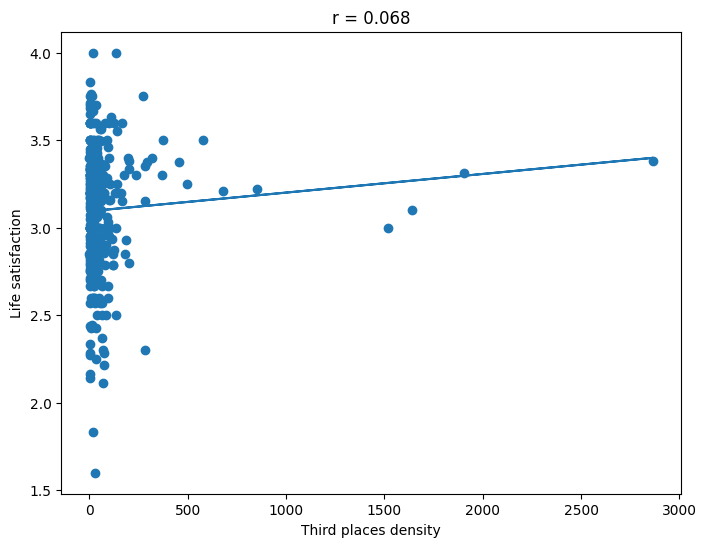

In [30]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# =========================================================
# COLAPSAR SATISFACCIÓN A NIVEL CIUDAD
# =========================================================

city_life = (
    df24
    .groupby("CIUDAD", as_index=False)["life_satisfaction"]
    .mean()
)

# agregar label ciudad
city_life["city"] = city_life["CIUDAD"].map(ciudad_labels)

# =========================================================
# MERGE CON THIRD PLACES
# =========================================================

df_plot = city_life.merge(
    df_third_places,
    left_on="city",
    right_on="city",
    how="inner"
)

# limpiar missings
df_plot = df_plot.dropna(
    subset=["life_satisfaction", "third_places_density"]
)

# =========================================================
# PEARSON
# =========================================================

r, p = pearsonr(
    df_plot["third_places_density"],
    df_plot["life_satisfaction"]
)

print(f"Pearson r = {r:.3f}")
print(f"p-value = {p:.5f}")

# =========================================================
# SCATTER PLOT
# =========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    df_plot["third_places_density"],
    df_plot["life_satisfaction"]
)

# línea de tendencia
z = np.polyfit(
    df_plot["third_places_density"],
    df_plot["life_satisfaction"],
    1
)

pfit = np.poly1d(z)

plt.plot(
    df_plot["third_places_density"],
    pfit(df_plot["third_places_density"])
)

plt.xlabel("Third places density")
plt.ylabel("Life satisfaction")
plt.title(f"r = {r:.3f}")

plt.show()

In [15]:
df_third_places[
    df_third_places["third_places_density"] > 1
][[
    "city",
    "country",
    "tamciud",
    "third_places",
    "third_places_density"
]].sort_values("third_places_density", ascending=False)

,city,country,tamciud,third_places,third_places_density
183,CL: Metropolitana-El Bosque,Chile,1,542,6.900958
101,CR: San Jose-San Jose,Costa Rica,3,1857,2.627118
98,CR: San Jose-Goicoechea,Costa Rica,3,1833,2.593165
114,CR: Heredia-Heredia,Costa Rica,3,970,1.372269
102,CR: San Jose-Tibas,Costa Rica,4,1700,1.352817
100,CR: San Jose-Moravia,Costa Rica,4,1491,1.186500
95,CR: San Jose-Curridabat,Costa Rica,4,1447,1.151486
99,CR: San Jose-Montes de Oca,Costa Rica,4,1425,1.133979
